# Assignment 3: Dissipative Particle Dynamics

**6EMA02 Particle-based Simulations, 2026-2027 edition**
Mesoscale simulation · soft repulsive beads · demixing and interfaces

## How this assignment is assessed: read this first

This notebook is both the assignment text and your report. Task cells
(like this one) are the assignment text and are marked read-only. Jupyter
enforces that; some editors (VS Code among them) do not, so simply leave
them untouched either way: hand-ins are checked against the released
notebook, and modified task cells are flagged. You write your answers in
the cells below each task and hand in this same notebook, **executed**,
together with an HTML export, your code, and the data files the notebook
loads (layout at the end of this notebook).

Your report is **not graded on its content**. Its result is determined in
the individual oral examination at the end of the quartile: the exam is a
conversation about *your* code and *your* results, with this notebook on
screen. Write it as your defence dossier: concise, bullet answers are
fine, every claim something you can stand behind. A report you never hand
in scores 0 for its weight in the final grade; a handed-in report's
result *is* your oral grade.

**AI and sources.** You may use AI assistants (ChatGPT, Claude, Copilot,
…) freely in this course, for code, analysis, and text. Declare the use
briefly in the *Sources* section below, along with any other external
sources: anything in your submission (code, text, data, results) that
your group did not produce itself. Declared sources are never penalised:
nobody grades the text of your report or the style of your code. The oral
examination assesses what *you* understand about the simulation you hand
in. Anything in your submission is fair game, and "we didn't write that
part" is not an available answer. Presenting undeclared external work as
your own is academic misconduct and is treated as such.

## Group

- **Group ID:** A3_6
- **Members:** Jacob (Job) Scheepens (2364654), name (student ID)

## The physics: why a mesoscale method exists

Your A2 code integrates the motion of individual molecular sites with a
time step of about a femtosecond. Now consider what you would need to
simulate a droplet of oil in water demixing, or a polymer solution
flowing through a channel: micrometres of space and microseconds of time.
That is roughly $10^{12}$ sites and $10^{9}$ steps. Molecular dynamics
cannot get there, and continuum fluid mechanics cannot resolve the
individual polymer chains that matter. **Dissipative particle dynamics
(DPD) lives in that gap.**

The trick is **coarse-graining**. One DPD bead is not an atom: it stands
for a lump of fluid, a cluster of molecules moving together. Because a
bead is a soft blob rather than a hard molecule, two beads may overlap,
and the repulsion between them is **soft**:

$$\mathbf{F}^C_{ij} = a_{ij}\left(1 - \frac{r_{ij}}{r_c}\right)
\hat{\mathbf{r}}_{ij} \quad \text{for } r_{ij} < r_c,$$

finite even at $r_{ij} = 0$. No $r^{-12}$ wall means no violently fast
collisions, which is what buys the very large time steps that make the
method useful.

Coarse-graining throws away degrees of freedom, and they must come back
as noise and friction. DPD adds two more pair forces:

$$\mathbf{F}^D_{ij} = -\gamma\, \omega^D(r_{ij})
(\hat{\mathbf{r}}_{ij} \cdot \mathbf{v}_{ij})\, \hat{\mathbf{r}}_{ij},
\qquad
\mathbf{F}^R_{ij} = \sigma\, \omega^R(r_{ij})\, \frac{\zeta_{ij}}
{\sqrt{\Delta t}}\, \hat{\mathbf{r}}_{ij}.$$

The dissipative force damps the *relative* velocity of a pair, the random
force kicks it. Neither is arbitrary: the **fluctuation-dissipation
theorem** ties their amplitudes and their weight functions together
(Eq. (5) of the paper, with $\omega^D = [\omega^R]^2$ and
$\sigma^2 = 2\gamma k_BT$). Get that relation wrong and your system
simply equilibrates to the wrong temperature, which is exactly what task
B3 checks.

The decisive property is that **all three forces act pairwise along the
line between beads**, so they conserve momentum. That is the difference
between DPD and Brownian or Langevin dynamics, where the friction is with
an implicit background that absorbs momentum. Conserved momentum means
the correct long-wavelength behaviour emerges by itself: DPD reproduces
hydrodynamics, so a DPD fluid flows, carries shear, and mediates
hydrodynamic interactions between suspended objects. That is what makes
it a *mesoscale* method rather than a fast approximation.

What does a bead stand for, quantitatively? Groot and Warren fix that by
matching the compressibility of water at $\rho = 3$, giving
$a_{ii} \approx 25\, k_BT/r_c$ for beads of the same type. Different
types repel more strongly, $a_{ij} > a_{ii}$, and the excess drives
demixing. The link to polymer physics is the Flory-Huggins parameter
$\chi$, which you will measure in task C3 and which turns out to depend
linearly on $\Delta a = a_{AB} - a_{AA}$. Add springs between beads and
you have polymer chains, whose demixing at much smaller $\Delta a$ (the
$\chi N$ of Eq. (27)) is the subject of Part D.

## What you will do, and the reference paper

You will convert **your own MD code from Assignment 2** into a DPD code,
verify it, and then use it to reproduce published results. There is no
new starting code for A3, and so no `\todo` list to guide you: everything
you have to build is stated in this notebook, in the section *From your
A2 code to a DPD code* below and in the task texts. Read both before you
change a line.

The reference is Groot and Warren, *J. Chem. Phys.* **107**, 4423
(1997), handed out under Files ▸ Papers. Equation and figure numbers in
this notebook refer to that paper. Reproducing a published result is the
strongest form of validation available to you here: the numbers exist
independently of your code, so agreement is evidence and disagreement is
information.

**Units: not the units of A2.** In A2 the energy unit was $k_B \times
1$ K, lengths were in Å and masses in amu, so $k_BT = 293$, the masses
were about 15, the cut-off was 14 and the time step 0.001 (about 1 fs).
DPD uses its own reduced units: the cut-off distance $r_c$ of the DPD
interactions is the unit of length, the bead mass $m$ the unit of mass,
and the thermal energy $k_BT$ the unit of energy. The time unit follows
as $r_c\sqrt{m/k_BT}$. So $r_c = m = k_BT = 1$, and **every number in
your A2 `setparameters.c` changes**; the table in the next section lists
them. Report everything in these units unless you say otherwise.

**The integrator stays.** Groot and Warren's Eq. (9) is a velocity-Verlet
step in which the velocity-dependent forces of the new time step are
evaluated with a predicted velocity $\tilde{\mathbf{v}} = \mathbf{v}(t) +
\lambda \Delta t\, \mathbf{f}(t)/m$. Your A2 loop already does this with
$\lambda = 1/2$: it calls `calculate_forces` after the first half kick and
the position update, so the velocities the force routine sees are exactly
$\mathbf{v}(t) + \tfrac12 \Delta t\, \mathbf{f}(t)/m$. Keep the loop as it
is. Use $\Delta t = 0.04$ for all thermostatted runs, as the paper does.

Expect the conversion to be where the bugs are. Take small steps, run a
short simulation after each change, and look at it in OVITO before you
measure anything.

**Your working environment** is the one you set up for A1 and A2: the
`pbs-env` environment from `requirements.txt`, `nb2html.py` for the HTML
you hand in, and `check_my_submission.py` before you submit. See the
Canvas page *Working on the assignments*.

## From your A2 code to a DPD code

This is the inventory: what you can keep, what you must change, and what
you must write from nothing. Names refer to the A2 starting code; if you
renamed things in A2, map them onto your own.

**Keep as it is.** The velocity-Verlet loop in `main.c` and the two
routines in `dynamics.c` it calls (`update_velocities_half_dt`,
`update_positions`); `boundary_conditions`; the cell list and neighbour
list in `nbrlist.c`; `v3_min_image` and the other vector helpers; the
restart files; the bond list built in
`initialise_bond_connectivity` and `initialise_structure`; and the
finite-difference force test. The test still works for the conservative
force and the springs, which derive from a potential, provided you switch
the dissipative and random forces off while it runs; it cannot test those
two, which derive from no potential.

**Change.**

| A2 | A3 |
|---|---|
| $k_BT = 293$, masses 15.035 and 14.027 | $k_BT = 1$, both masses 1 |
| `r_cut = 14`, `r_shell = 1` | `r_cut = 1`, `r_shell` about 0.3 to 0.4 |
| `dt = 1e-3` | `dt = 0.04` (task B1 uses smaller values) |
| cubic box from the mass density | box in units of $r_c$, `num_part` $= \rho L_x L_y L_z$ with $\rho = 3$ (see the run plan) |
| Lennard-Jones $\epsilon_{ij}$, $\sigma_{ij}$ per type pair | DPD repulsion $a_{ij}$ per type pair; two types, A and B |
| bond $\tfrac12 k_b (r - r_0)^2$, $r_0 = 1.54$ | the same routine with $r_0 = 0$ and $k_b = C = 2$: that *is* Eq. (25) |
| angle and torsion terms | **removed**: delete their calls from `calculate_forces`. `initialise_structure` derives angles and dihedrals from the bonds by itself, so leaving the calls in applies pentane angle and torsion forces to your chains |
| `factor_12_nb = factor_13_nb = factor_14_nb = 0` | **all three equal to 1**: in DPD bonded beads also repel each other (task A2) |
| CH$_3$ and CH$_2$ in fixed pentane order | type A or B per chain, a chosen fraction of each (task A2) |
| 5 sites per molecule, 4 bonds | chains of $N$ beads, $N - 1$ bonds; $N = 1$ means no bonds at all |
| pentanes on a lattice | random-walk chains, optionally A and B in separate halves of the box (task A2, Part C) |
| Berendsen thermostat, `is_NVT = 1` | **removed**: the dissipative and random forces are the thermostat, and rescaling the velocities on top of them destroys the fluctuation-dissipation balance they rely on |
| output and sampling intervals, in steps | check each one: a step is now $0.04$ time units, not 1 fs |
| `record_trajectories_pdb` labels every site C | OVITO then sees one particle type. If your A beads come first, colour by index: *Expression selection* with `ParticleIndex <` (number of A beads), then *Assign color*. Otherwise write the type into the file, for instance as the element name: one line in the writer |

**Write new.**

- The three DPD pair forces in `calculate_forces_nb` (task A1). They need
  the velocities and the time step, which the Lennard-Jones loop never
  used, and a source of random numbers.
- Two switches in `setparameters.c`, one for the conservative force and
  one for the dissipative and random forces together. Part B runs with
  each of them off in turn.
- On-the-fly analysis, most of it new: $g(r)$ per type pair (A3); the
  velocity distribution (B3), which you may already have from A2; the
  composition profile along $x$ (Part C); the diagonal components of the
  pressure tensor (C4); the end-to-end distance of the chains (D1).

## The runs, at a glance

Every run is a separate compilation with its own `setparameters.c`
values, as in A2. Density $\rho = 3$ throughout and
$a_{AA} = a_{BB} = 25$; $\Delta a = a_{AB} - 25$. The step counts are a
suggestion that is known to be enough. For orientation, a reference DPD
code of the same structure as yours does 60 000 steps of 6000 beads in
about five minutes on one core.

| runs | box | beads | $N$ | $a_{AB}$ | switches, $\Delta t$ | steps | tasks |
|---|---|---|---|---|---|---|---|
| energy | $10^3$ | 3000 | 1 | 25 | dissipative and random **off**; $\Delta t$ = 0.04, 0.02, 0.01, 0.005; start from the end of the monomer-fluid run | to $t = 200$ | B1 |
| ideal gas | $10^3$ | 3000 | 1 | 25 | conservative **off** | 20 000 | B2, B3 |
| monomer fluid | $10^3$ | 3000 | 1 | 25 | all on | 20 000 | B3, C1 |
| Fig. 6 | $20\times10\times10$ | 6000 | 1 | 37 | all on, separated start | 60 000 | C2 |
| χ series | $20\times10\times10$ | 6000 | 1 | 35, 39, 43, 47 | all on, separated start | 60 000 each | C3, C4 |
| control | $20\times10\times10$ | 6000 | 1 | 25 | all on, separated start | 60 000 | C4 |
| chains | $10^3$ | 3000 | 5 | 25 | all on | 20 000 | D1 |
| chain demixing | $20\times10\times10$ | 6000 | 3, 5, 10 | 28 | all on, separated start | 60 000 each | D2, D3 |
| chain χ series | $20\times10\times10$ | 6000 | 3; 5; 10 | 30, 32; 27, 28.5, 30; 26, 26.5, 27 | all on, separated start | 60 000 each | D3 |

Long runs are done in the terminal, never from the notebook; let the
notebook load their output from `data/`.

## Code map: fill in as you go

The examiner uses this table in the oral to jump straight to your code,
so **make the entries clickable links**: a markdown link with a path
relative to this notebook, for example

```
| A1 DPD forces | [`calculate_forces_nb`](code/forces.c) | [gr_a25.csv](data/gr_a25.csv) |
```

Relative paths only (`code/…`, `data/…`); everything you link to must be
inside the zip you hand in. `check_my_submission.py` verifies this.

| Task | File / function(s) | Data files |
|------|--------------------|------------|
| A1 DPD forces | … | … |
| A2 bead-spring chains, initialisation | … | … |
| A3 g(r) | … | … |
| B1 energy conservation | … | … |
| C2/C3 composition profile, χ | … | … |
| C4 pressure tensor, surface tension | … | … |
| D1 chain size | … | … |

## Sources

**AI tools used:** … / none.
**Used for:** … .
**Other external sources** (code, text, data, or results not produced by
us): … / none.
**Parts of the submission with substantial external content:** … .
**What we did ourselves to verify these parts:** … .

## Build & run log

Exact compile and run commands, machine, and approximate wall-clock time
for each production run whose output sits in `data/`:

- …

## Part A: Implementing the DPD method

*In the oral you should be able to:* explain each of the three DPD pair
forces and what it does to the system's energy and momentum; explain the
$1/\sqrt{\Delta t}$ in the random force; explain why σ and γ are not
independent, and why the Berendsen thermostat had to go.

### A1) DPD pair forces

Replace the Lennard-Jones interaction in `calculate_forces_nb` by the DPD
pair forces of Eqs. (3), (4) and (8): the conservative force
$\mathbf{F}^C$, the dissipative force $\mathbf{F}^D$, and the random
force $\mathbf{F}^R$, with the weight functions of Eq. (6) and all
three zero beyond $r_c$. Use $\gamma = 4.5$ and derive $\sigma$ from
the fluctuation-dissipation relation, Eq. (5). For the random force use
$\zeta_{ij}$ with mean zero and variance 1; uniformly distributed numbers
from $[-\sqrt{3}, \sqrt{3}]$ are recommended (see the discussion on
p. 4426 of the paper). Make the conservative force type-dependent,
$a_{ij}$ per pair of types, stored the way A2 stored $\epsilon_{ij}$.

The potential energy your routine returns is that of the conservative
force alone: the other two derive from no potential. Accumulate the
virial from the conservative force only, as in the second line of
Eq. (15).

Document in the cell below: the value of $\sigma$ you derived and from
which relation; how you ensured that $\zeta_{ij} = \zeta_{ji}$ for a pair
(what would break if it were not?); and where in your step the random
force is drawn, given that it depends on $\Delta t$.

*Implementation notes (A1):* …

$\sigma =  \sqrt{2\gamma \mathrm{k}_b T}$

$\mathrm{\zeta}_{ij} = \mathrm{\zeta}_{ji}$ is ensured by implementing the gaussian only once per pair in the neighbour list and uses that same force for both particles.

The random force is drawn after the positions and boundary consitions are updated, but before the second half-step velocity update.



### A2) Bead-spring chains

Adapt the code to chains of $N$ beads: `initialise_bond_connectivity`
must bond bead $k$ to bead $k+1$ within each chain, and
`initialise_types` must give all beads of a chain the same type, A or B.
The spring force between bonded beads is

$$\mathbf{f}_{ij} = -C\,\mathbf{r}_{ij}, \qquad C = 2\,k_BT\,r_c^{-2}$$

(note the sign error in the paper's Eq. (25); the spring is always
attractive). This is your A2 bond force with rest length zero.

Bonded pairs must **also** interact through the DPD pair forces. In A2
the excluded pairs would have overlapped the steep Lennard-Jones core,
and the bonded terms already described their interaction. Neither holds
here: the DPD repulsion is soft, and a chain bead is the same bead as a
monomer, with the same repulsion from every neighbour. In the A2 code
that means setting `factor_12_nb`, `factor_13_nb` and `factor_14_nb` to
**one**, the opposite of A2: a factor zero excludes a pair, and a factor
one treats it like any other pair (and skips the connectivity lookup
altogether).

Write an initialisation for chain systems that avoids overstretched
springs, for instance each chain as a random walk with steps of about
the mean bond length. Give it an option to start all A chains in the
half $x < L_x/2$ and all B chains in $x > L_x/2$, which every demixing
run of Parts C and D uses.

Document your initialisation, and state what would go wrong physically
if 1-2 and 1-3 pairs *were* excluded here, given that this is the
opposite of what you did in A2.

*Implementation notes (A2):*

Demixed Initialization: (chain length = 5, not easily seen in OVITO)

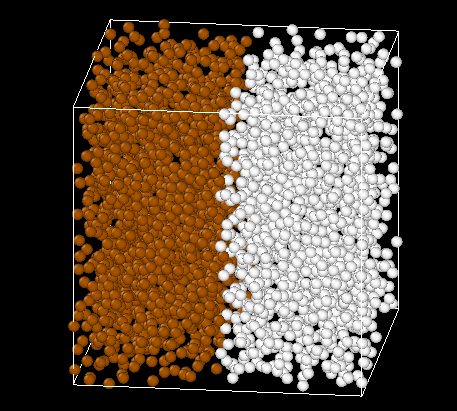



Normal Initialization: (chain length = 5, not easily seen in OVITO)

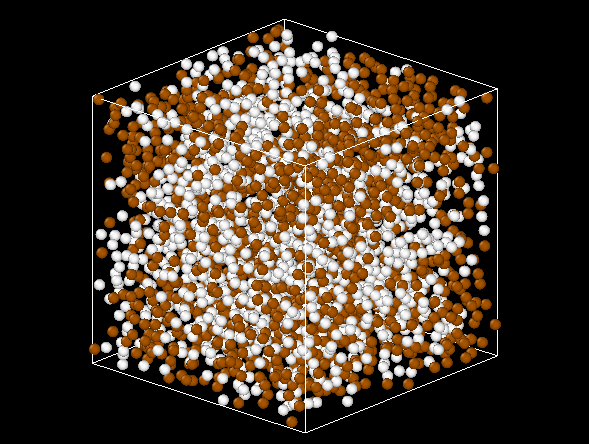

If the 1-2 and 1-3 pairs were excluded in this program the conservative, dissipative and random forces would not be implemented for the 1-2 and 1-3 pairs.

### A3) Radial distribution function

Implement on-the-fly calculation of the radial distribution function
$g(r)$, per type pair (AA, AB, BB), up to $r = 3$. State your bin width
and the normalisation you used, and how you convinced yourself the
normalisation is right (a run whose answer you know in advance is the
cheapest way; task B2 gives you one).

*Implementation notes (A3):*

The bin width used is 0.05, which gives 60 bins between r=0 and r=3.
In each bin the code counts pairs which minimum-image distance falls between r=0 and r=3 and then compares the count with the expected number is they would be uniformly distributed in the box.

The g(r) function is then checked using the B2 run.

## Part B: Verification for monomers (N = 1)

*In the oral you should be able to:* say which bug classes each of these
three tests isolates, and why together they cover the code; derive the
conservative pair potential; explain why the energy-conservation run
needs a smaller timestep than a thermostatted run.

These three tests are designed to be run with parts of the physics
switched off, which is what makes them sharp: each isolates one layer of
the implementation. All three use the cubic box of side 10 with 3000
monomers and $a = 25$ (see the run plan).

### B1) Energy conservation

Derive the potential energy expression belonging to the conservative pair
force. Disable the dissipative and random interactions and verify
conservation of total energy.

Start these runs from an equilibrated state: the restart file written at
the end of the thermostatted monomer-fluid run, as you used restart files
in A2. Your initial positions are random, and their overlaps release so
much potential energy that a run without the thermostat heats itself to
well above $k_BT = 1$: still a test of energy conservation, but not of the
state you simulate everywhere else.

Deliver:

- the derivation of $U^C(r)$ from $\mathbf{F}^C$, and its value at
  $r = 0$;
- a **figure** of total, kinetic and potential energy against time for
  the conservative-only run;
- a **table** of the relative energy drift for at least three time steps
  ($\Delta t$ = 0.04, 0.02, 0.01, 0.005 are suggested), each run to the
  same physical time, with the observed scaling stated. Do not be alarmed
  if the largest time step does not conserve energy at all: say what you
  see, and explain why this run needs a smaller $\Delta t$ than your
  thermostatted production runs do.

*Results (B1):* …

In [ ]:
# B1: energy vs time, conservative-only run; drift against dt

### B2) Ideal-gas structure

Disable the conservative interactions, keeping the dissipative and random
forces on. The beads then interact only through friction and noise, so
their equilibrium structure must be that of an ideal gas.

Deliver a **figure** of $g(r)$ for this run, showing it is flat and equal
to 1 within the noise, and a sentence on what a *non*-flat result would
have told you (this test catches both a broken $g(r)$ normalisation and a
conservative force that is not really off).

### B3) Velocity statistics

Verify that the velocity distribution matches the imposed temperature
(Maxwellian, with the correct variance), independent of the conservative
interactions.

Deliver:

- a **figure** of the velocity histogram with the Maxwell-Boltzmann
  prediction on top, for a run with the conservative force on and one
  with it off;
- a **table** of the measured $k_BT$ from the variance in both cases,
  next to the imposed value, and a sentence comparing the deviation you
  find with what Groot and Warren report for the Verlet scheme with
  $\lambda = 1/2$ at $\Delta t = 0.04$ (Fig. 1 and the text beside it);
- a short statement of what this verifies about your $\sigma$ and
  $\gamma$: if you had used a wrong fluctuation-dissipation relation,
  what would this table look like?

*Results (B2, B3):* …

In [ ]:
# B2/B3: flat g(r); velocity histogram against Maxwell-Boltzmann

## Part C: Validation for monomers (N = 1)

*In the oral you should be able to:* say what agreement with a published
simulation result does and does not validate; explain how χ is measured
from composition profiles and what must be true of the profiles first;
explain the sign, magnitude and factor of two of your surface tension.

**Every demixing run** (C2, C3, C4, and Part D) uses the same geometry.
The box is $20 \times 10 \times 10$, elongated along $x$, with 6000
beads, and starts with A in the half $x < 10$ and B in the half
$x > 10$. The two phases then form two flat slabs with **two flat
interfaces perpendicular to $x$**, and the two bulk regions are wide
enough to read a composition from. In a cubic box the system can
separate along any axis, or not into flat slabs at all, and then
neither the composition profile nor the surface tension means anything.
Groot and Warren elongate their box along $z$; we use $x$ throughout, so
read their $z$ as our $x$.

The **composition profile** is the number density of A and of B in thin
slabs perpendicular to $x$ (a bin width of about 0.2 to 0.5), averaged
over the run after equilibration, and the A fraction
$\phi_A(x) = \rho_A / (\rho_A + \rho_B)$ computed from them. Write it out
in blocks during the run (every few thousand steps), not only once at
the end: C2 asks when the profile became steady, and the error estimates
of C3 come from the scatter between blocks.

### C1) Radial distribution function

Reproduce the $g(r)$ of Fig. 2 ($\rho = 3$, $a = 25$).

Deliver a **figure** with your $g(r)$ and the published curve on the same
axes (digitise a few points from the figure if you have no data file),
and a sentence on where they agree and where they do not. State your run
length and how you know $g(r)$ has converged.

*Results (C1):* …

In [ ]:
# C1: g(r) overlaid with Fig. 2

### C2) Binary demixing

Reproduce the phase separation of Fig. 6, using the parameters in its
caption ($a_{AB} = 37$) and the geometry above.

Deliver:

- a **snapshot** of the demixed system (OVITO, beads coloured by type);
- a **figure** of the composition profile along $x$, showing the two
  bulk plateaus and the two interfaces;
- a statement of how long the run needed to reach a steady profile, and
  how you decided it had.

*Results (C2):* …

In [ ]:
# C2: composition profile; snapshot

### C3) Measuring the χ-parameter

Measure χ with Eq. (18) from the composition profiles of demixed runs at
$\rho = 3$, for this edition's series

$$a_{AB} \in \{35,\ 39,\ 43,\ 47\}, \qquad a_{AA} = a_{BB} = 25 .$$

For monomers $N_A = 1$, and $\phi_A$ in Eq. (18) is the A fraction in the
bulk of the B-rich phase. Read it from the plateau of the profile, away
from both interfaces.

Deliver:

- a **figure** with the four composition profiles;
- a **table** of the bulk compositions and the resulting χ per $a_{AB}$,
  each with an error estimate;
- a **figure** of χ against $\Delta a = a_{AB} - a_{AA}$ with a linear
  fit, the fitted slope stated, and the slope of Eq. (24) (Fig. 7) for
  comparison. Groot and Warren fit only the points with $\chi > 3$
  (p. 4429), with the same integrator and $\Delta t$ as yours: compare
  like with like, and report the fit over all four points as well.

Then state what must be true of the profiles before Eq. (18) may be
applied at all, and confirm that it is true of yours.

*Results (C3):* slope …, comparison with Eq. (24) …

In [ ]:
# C3: composition profiles; chi against Delta a with linear fit

### C4) Surface tension  *(new this edition)*

For the same demixed runs as C3, obtain the interfacial tension from
Eq. (31). With the interface normal along $x$ it reads

$$\sigma_s = \int \left[ p_{xx}(x) - \tfrac12\big(p_{yy}(x) + p_{zz}(x)\big) \right] dx ,$$

the normal minus the tangential pressure, integrated across the
interface. You do **not** need the pressure as a function of $x$. What
you need is this:

1. **The diagonal of the pressure tensor of the whole box**, at every
   sampling step:
   $P_{\alpha\alpha} = \frac{1}{V}\big[\sum_i m v_{i\alpha}^2 + \sum_{i<j}
   r_{ij,\alpha} F_{ij,\alpha}\big]$, $\alpha = x, y, z$, with
   $\mathbf{F}_{ij}$ the conservative and spring forces, as in
   Eq. (15). Your A2 code accumulates only the scalar virial
   $\sum \mathbf{r}_{ij} \cdot \mathbf{F}_{ij}$; accumulate its three
   components separately, in the same place.
2. **The step from Eq. (31) to those three numbers.** Take the integral
   over the whole periodic box. Derive $\sigma_s$ in terms of $L_x$ and
   the box averages $P_{xx}$, $P_{yy}$, $P_{zz}$, say where the **two**
   interfaces in the box enter, and explain why the bulk regions add
   nothing to the integral.
3. **A time average with an honest error.** Successive samples are
   strongly correlated, so the naive standard error of the mean is too
   small; use block averages.
4. **A control run** at $a_{AB} = 25$, with the same separated start: one
   phase, no interface, so $\sigma_s$ must vanish within its error. That
   checks your tensor for a bias between $x$ and the other two directions;
   a wrong overall factor would pass it, so check the magnitude too,
   against Groot and Warren's monomer surface tension, Eq. (36).

Deliver:

- a **table** and a **figure** of $\sigma_s$ against $\Delta a$, with
  error bars, including the control;
- your derivation of item 2;
- a discussion of three things: the **sign** of $\sigma_s$ and why it
  must be that sign for a stable interface; the **trend** with
  $\Delta a$; and the **limit** as $\Delta a$ approaches the mixing
  point, where the two phases become identical.

*Results (C4):* …

In [ ]:
# C4: sigma_s against Delta a, with the control

## Part D: Validation for chains (N > 1)

*In the oral you should be able to:* explain why longer chains demix at
smaller Δa, and what Eq. (27)'s χN means for a symmetric blend.

For chains of equal length $N_A = N_B = N$, Eq. (18) gives the product
$\chi N$, with $\phi_A$ the fraction of A **beads** in the B-rich phase.
Demixing is governed by $\chi N$, so the values of $\Delta a$ that work
for monomers are far too large for chains: at $\Delta a = 16$ every chain
length used here demixes completely, no A bead is left in the B-rich
phase, $\phi_A = 0$ and Eq. (18) cannot be evaluated. That is why Part D uses
much smaller $\Delta a$, and different values for each $N$ (see the run
plan). Close to its critical point every interface is wide, and a chain
is several bead diameters long: check, for each run, that the part of the
profile you call bulk is really flat.

### D1) Snapshot

Provide a **snapshot** of equilibrated bead-spring chains with $N = 5$
($a = 25$ for every pair, cubic box), and a **number** characterising the
chains themselves: the mean-square end-to-end distance, compared with
that of an ideal chain with the same springs (derive it: $N - 1$
independent harmonic bonds with spring constant $C$). This is your check
that the springs and the initialisation are doing what you think; say
why the two numbers need not agree.

### D2) Two-phase simulations

Perform demixing simulations for chain lengths $N = 3$, $5$ and $10$, all
at $\Delta a = 3$ ($a_{AB} = 28$).

Deliver a **figure** with the composition profiles of the three chain
lengths on one set of axes, in the style of Fig. 6, so the effect of $N$
is visible in one figure, and a **snapshot** of each.

### D3) χ-parameter for chains

Measure χ for the chain systems, with a separate series of $\Delta a$
for each chain length:

| $N$ | $\Delta a$ |
|---|---|
| 3 | 3, 5, 7 |
| 5 | 2, 3.5, 5 |
| 10 | 1, 1.5, 2 |

($N = 3$ at $\Delta a = 3$ is the D2 run.)

Deliver a **table** of χ and $\chi N$ against $N$ and $\Delta a$, and a
**figure** comparing your $\chi N/\Delta a$ with Eq. (27) and Fig. 8.
Then answer the physical question: at fixed $\Delta a$, why do longer
chains demix more readily? Argue it from your table, from $\chi N$
rather than from the pictures.

*Results (D1-D3):* …

In [ ]:
# D: chain statistics, composition profiles, chi(N) against Eq. (27)

## Lessons learned

What would you do differently if you started over? What surprised you?
What broke first in the conversion from MD to DPD, and how did you find
it? (Standing questions in the oral, so write the honest version.)

*Lessons learned:* …

## Hand-in

One zip per group, layout exactly:

```
<group>_A3.zip
├── A3.ipynb     this notebook, filled in and executed
│                (all outputs present; task cells untouched)
├── A3.html      python3 nb2html.py A3.ipynb
├── code/        all .c/.h + README.md; must build with
│                gcc -O3 *.c -o dpd -lm    (no binaries)
└── data/        every data file this notebook loads
```

Long runs are done in the terminal; record the exact commands in the
*Build & run log* and let the notebook load the saved output from
`data/`. Handed in executed, the notebook must open and display without
rerunning anything.

**Before you submit,** check your own zip:

```
python3 check_my_submission.py <group>_A3.zip --release A3.ipynb
```

where `--release` is a freshly downloaded, unmodified `A3.ipynb`. It
verifies the layout, that the task cells are untouched, that every cell
has been executed, that your C code compiles, and that every path and
link in the notebook is relative and present in the zip. Fix what it
reports, then submit. Setting up the Python environment
(`requirements.txt`, both helper scripts) is described on the Canvas page
*Working on the assignments*.